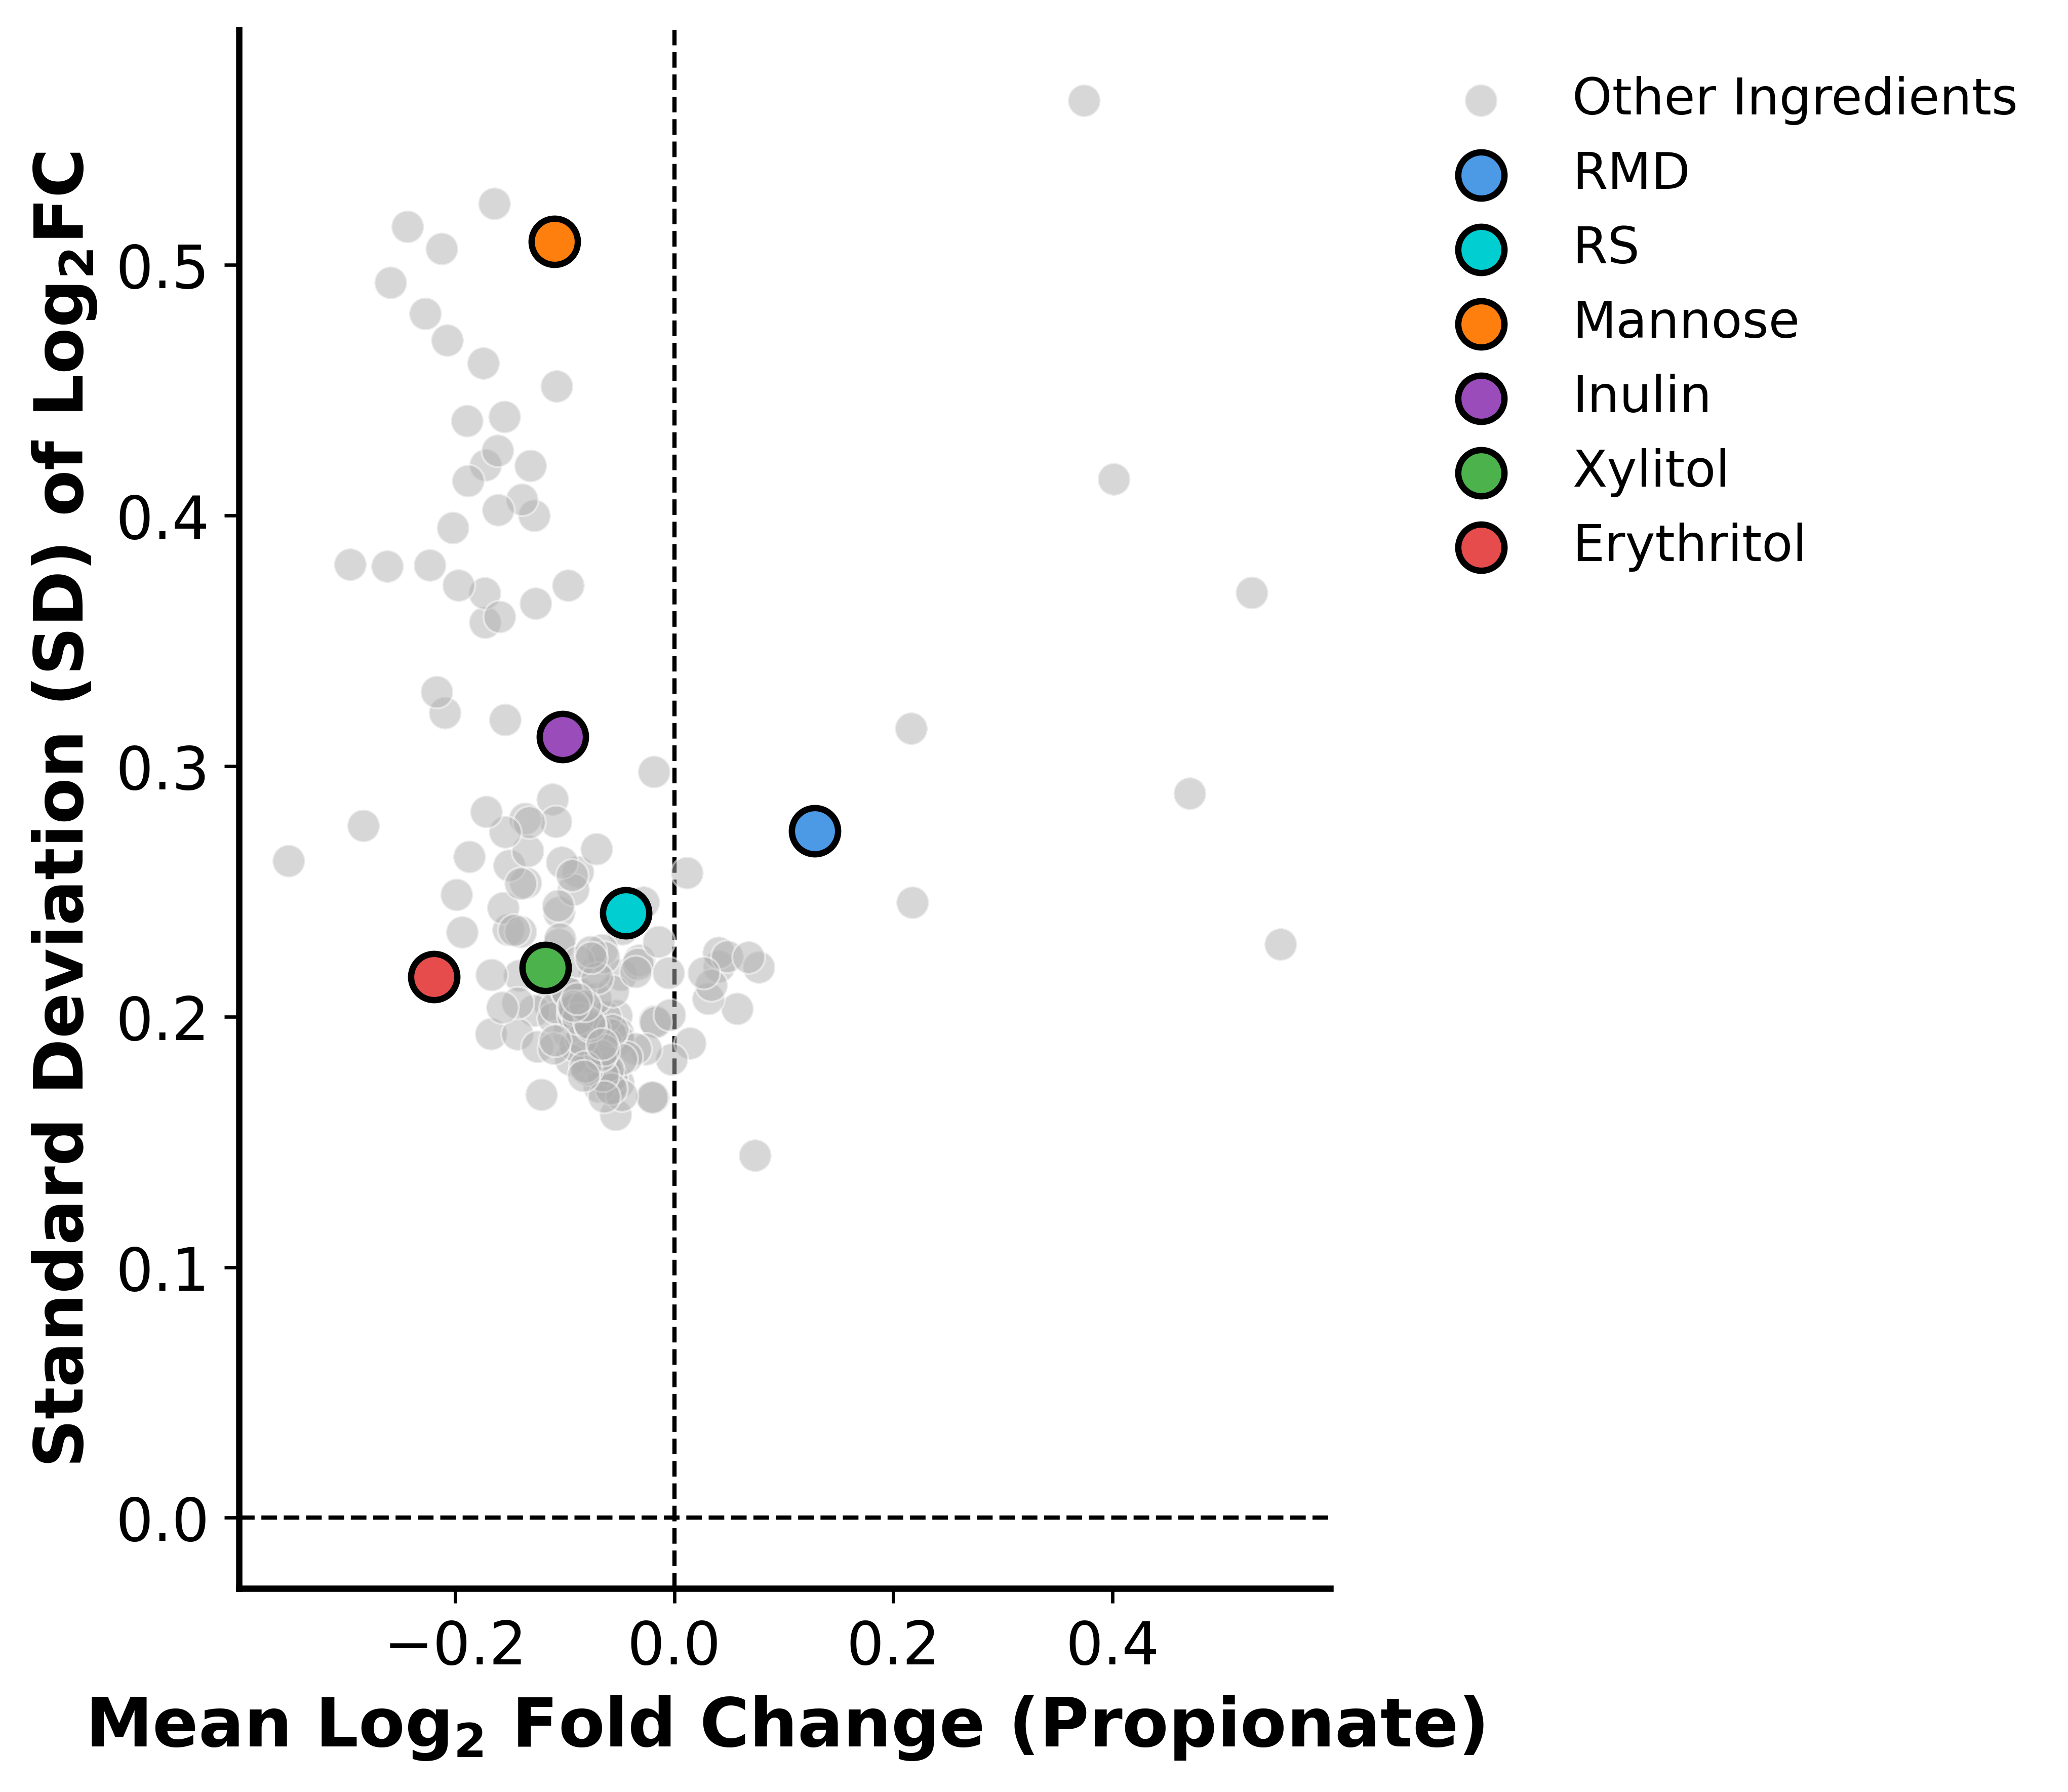

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# 1. Global Settings
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['pdf.fonttype'] = 42
DPI_SETTING = 600

# Color mapping matched to S3a
color_dict = {
    'RMD': '#4C99E6', 'RS': '#00CED1', 'Mannose': '#ff7f0e',
    'Inulin': '#9A4CBA', 'Xylitol': '#4CB34C', 'Erythritol': '#E64C4C', 'Other': '#B0B0B0'
}

def clean_and_convert_strict(vals):
    s_vals = pd.Series(vals).astype(str).replace(['Undetermined', '-', 'nan', 'NaN', '#VALUE!', ''], np.nan)
    return pd.to_numeric(s_vals, errors='coerce')

df_prop = pd.read_csv('Propionate(mM).csv')
donor_cols = [c for c in df_prop.columns if c.startswith('HS-')]

ctrl_mask = df_prop.iloc[:, 2].astype(str).str.contains('Control', case=False, na=False)
if not ctrl_mask.any(): ctrl_mask = df_prop.iloc[:, 0].astype(str).isin(['0', '000'])
ctrl_vals = clean_and_convert_strict(df_prop.loc[ctrl_mask, donor_cols].iloc[0].values)

plot_data = []
for idx, row in df_prop.iterrows():
    ingredient_name = str(row.iloc[2])
    if 'Control' in ingredient_name or 'Feces' in ingredient_name: continue

    treat_vals = clean_and_convert_strict(row[donor_cols].values)
    pair_df = pd.DataFrame({'Ctrl': ctrl_vals, 'Treat': treat_vals}).dropna()
    if len(pair_df) < 5: continue

    log2fc_vals = np.log2((pair_df['Treat'] + 0.01) / (pair_df['Ctrl'] + 0.01))

    # Classification
    category, zorder, alpha = 'Other', 1, 0.5
    name_lower = ingredient_name.lower()
    if 'maltodextrin' in name_lower: category, zorder, alpha = 'RMD', 5, 1.0
    elif 'starch' in name_lower: category, zorder, alpha = 'RS', 5, 1.0
    elif 'mannose' in name_lower: category, zorder, alpha = 'Mannose', 5, 1.0
    elif 'inulin' in name_lower: category, zorder, alpha = 'Inulin', 5, 1.0
    elif 'xylitol' in name_lower: category, zorder, alpha = 'Xylitol', 5, 1.0
    elif 'erythritol' in name_lower: category, zorder, alpha = 'Erythritol', 5, 1.0

    plot_data.append({
        'Ingredient': category, 'Mean': log2fc_vals.mean(), 'SD': log2fc_vals.std(ddof=1),
        'Color': color_dict[category], 'Zorder': zorder, 'Alpha': alpha
    })

df_plot = pd.DataFrame(plot_data)
order = ['RMD', 'RS', 'Mannose', 'Inulin', 'Xylitol', 'Erythritol']

# 3. Figure Generation
fig, ax = plt.subplots(figsize=(7, 6), dpi=DPI_SETTING)

others = df_plot[df_plot['Ingredient'] == 'Other']
ax.scatter(others['Mean'], others['SD'], c=others['Color'], alpha=others['Alpha'].iloc[0], s=60, edgecolors='white', linewidths=0.5, zorder=1, label='Other Ingredients')

for cat in order:
    target = df_plot[df_plot['Ingredient'] == cat]
    if not target.empty:
        ax.scatter(target['Mean'], target['SD'], c=target['Color'], alpha=target['Alpha'].iloc[0], s=120, edgecolors='black', linewidths=1.5, zorder=target['Zorder'].iloc[0], label=cat)

ax.axhline(0, color='black', linestyle='--', linewidth=1, zorder=0)
ax.axvline(0, color='black', linestyle='--', linewidth=1, zorder=0)

ax.set_xlabel(r'Mean Log$_{\mathbf{2}}$ Fold Change (Propionate)', fontsize=16, fontweight='bold')
ax.set_ylabel(r'Standard Deviation (SD) of Log$_{\mathbf{2}}$FC', fontsize=16, fontweight='bold')

ax.tick_params(axis='both', which='major', labelsize=14)
for s in ['top', 'right']: ax.spines[s].set_visible(False)
for s in ['left', 'bottom']: ax.spines[s].set_linewidth(1.5)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=12, frameon=False, bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig("Supplementary_Figure_S3b.pdf", dpi=DPI_SETTING, format='pdf', bbox_inches='tight', transparent=True)